# **Praktikum Latihan Mandiri 10 : K-Nearest Neighbors (KNN)**

# **LATIHAN 1**

# Import Library

In [5]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Dataset

In [6]:
df = pd.read_excel("https://docs.google.com/uc?export=download&id=1aBIMc_eKJQIXdboP-ccAC2W0knzK_RWY")
df

,temperatur_udara,kecepatan_angin,klasifikasi_persepsi marry
0,10,0,dingin
1,25,0,panas
2,15,5,dingin
3,20,3,panas
4,18,7,dingin
5,20,10,dingin
6,22,5,panas
7,24,6,panas


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   temperatur_udara            8 non-null      int64 
 1   kecepatan_angin             8 non-null      int64 
 2   klasifikasi_persepsi marry  8 non-null      object
dtypes: int64(2), object(1)
memory usage: 324.0+ bytes


# Fitur & Label

In [8]:
X = df[['temperatur_udara', 'kecepatan_angin']]
y = df['klasifikasi_persepsi marry']

# Split Data Train - Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

In [10]:
X_train, X_test

(   temperatur_udara  kecepatan_angin
 2                15                5
 4                18                7
 3                20                3
 6                22                5,
    temperatur_udara  kecepatan_angin
 1                25                0
 5                20               10
 0                10                0
 7                24                6)

# Training Model KNN

In [11]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [13]:
print("Akurasi model (k):", acc)

Akurasi model (k): 0.75


# Prediksi Data Test

In [14]:
test_data = pd.DataFrame([[16, 3]], columns=X.columns)
hasil = model.predict(test_data)

print("Persepsi Marry (16°C, 3 km/jam):", hasil[0])

Persepsi Marry (16°C, 3 km/jam): dingin


# Mencari Nilai K Terbaik

In [15]:
akurasi_k = {}

for k in range(1, len(X_train) + 1):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    akurasi_k[k] = accuracy_score(y_test, pred)

akurasi_k

{1: 1.0, 2: 1.0, 3: 0.75, 4: 0.5}

# Menampilkan K Terbaik

In [16]:
k_terbaik = max(akurasi_k, key=akurasi_k.get)
print("Nilai k terbaik:", k_terbaik)
print("Akurasi:", akurasi_k[k_terbaik])

Nilai k terbaik: 1
Akurasi: 1.0


# **LATIHAN 2**

# Import Library

In [17]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

In [18]:
df1 = pd.read_excel("https://docs.google.com/uc?export=download&id=1r5b5XXM7h9qdg8JM1ZQtRld0kgQgy3ZQ")
df1

,nim,hasil_sebenarnya,hasil_prediksi
0,TI001,Lulus,Lulus
1,TI002,Lulus,Lulus
2,TI003,Lulus,Lulus
3,TI004,Lulus,Tidak Lulus
4,TI005,Lulus,Tidak Lulus
5,TI006,Tidak Lulus,Lulus
6,TI007,Tidak Lulus,Tidak Lulus
7,TI008,Tidak Lulus,Tidak Lulus
8,TI009,Tidak Lulus,Tidak Lulus
9,TI010,Tidak Lulus,Tidak Lulus


In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df1["Actual_enc"] = encoder.fit_transform(df1["hasil_sebenarnya"])
df1["Pred_enc"] = encoder.transform(df1["hasil_prediksi"])

y_true = df1["Actual_enc"]
y_pred = df1["Pred_enc"]

# Confusion Matrix

In [20]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

cm_df1 = pd.DataFrame(cm,
                     index=["Actual Lulus", "Actual Tidak Lulus"],
                     columns=["Pred Lulus", "Pred Tidak Lulus"])

print("\nConfusion Matrix:")
display(cm_df1)


Confusion Matrix:


,Pred Lulus,Pred Tidak Lulus
Actual Lulus,3,2
Actual Tidak Lulus,1,4


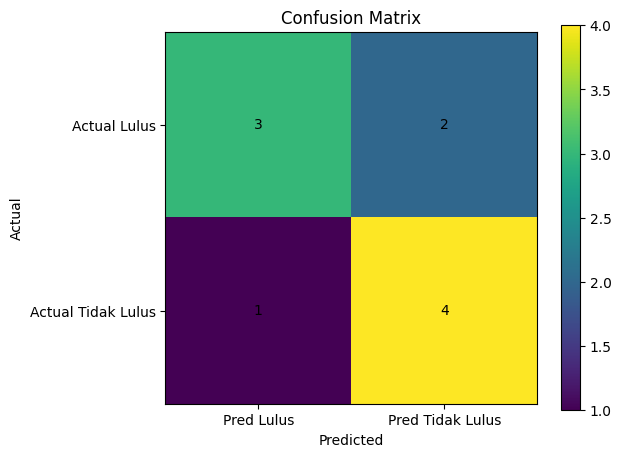

In [21]:
# Visualisasi Confusion Matrix (Heatmap)
plt.figure(figsize=(6,5))
plt.imshow(cm)

# Mengatur label
plt.xticks([0, 1], ["Pred Lulus", "Pred Tidak Lulus"])
plt.yticks([0, 1], ["Actual Lulus", "Actual Tidak Lulus"])

# Menampilkan nilai dalam kotak
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# Menghitung Accuracy, Precision, Recall

In [22]:
y_true = df1["Actual_enc"]
y_pred = df1["Pred_enc"]

accuracy = accuracy_score (y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=0)
recall = recall_score(y_true, y_pred, pos_label=0)

print("Akurasi", round (accuracy*100, 2), "% ")
print("Precision", round (precision*100, 2), "% ")
print("Recall", round (recall*100, 2), "% ")

Akurasi 70.0 % 
Precision 75.0 % 
Recall 60.0 % 


# **LATIHAN 3**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

In [24]:
import pandas as pd
df2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Machine Learning/Praktikum10/Data/weather_classification_data.csv")
df2.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [25]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


# Missing Value

In [26]:
print(df2.isnull().sum())

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64


# Encoding Kolom Kategori

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df2.columns:
    if df2[col].dtype == 'object':
        df2[col] = le.fit_transform(df2[col])

df2.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  int64  
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  int64  
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  int64  
 10  Weather Type          13200 non-null  int64  
dtypes: float64(5), int64(6)
memory usage: 1.1 MB


# Memisahkan fitur X dan y

In [29]:
y = df2["Weather Type"]
X = df2.drop("Weather Type", axis=1)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.8916666666666667


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')

print("Akurasi :", round(acc*100, 2), "%")
print("Precision :", round(prec*100, 2), "%")
print("Recall :", round(rec*100, 2), "%")

Akurasi : 89.17 %
Precision : 89.22 %
Recall : 89.08 %


# Confusion Matrix

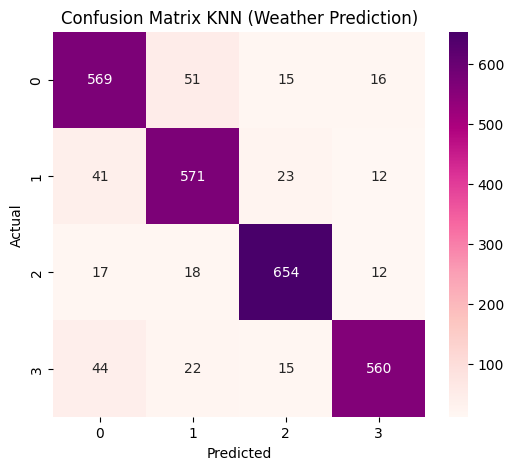

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu")
plt.title("Confusion Matrix KNN (Weather Prediction)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       651
           1       0.86      0.88      0.87       647
           2       0.93      0.93      0.93       701
           3       0.93      0.87      0.90       641

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640



# Elbow Method Pemilihan K Terbaik

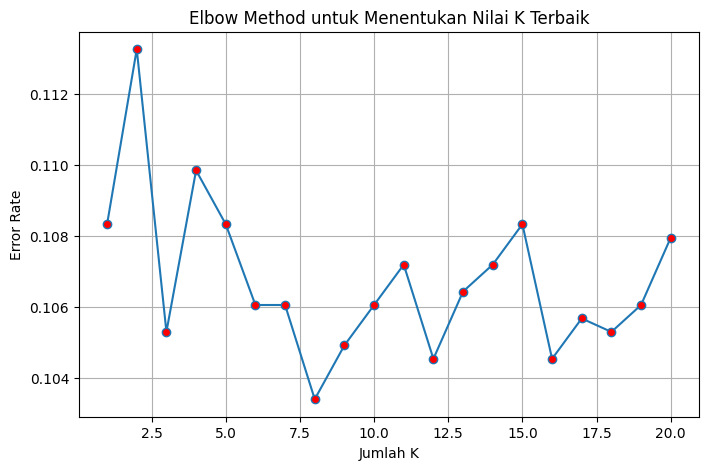

In [38]:
# Menentukan nilai K terbaik menggunakan Elbow Method
error_rate = []

for k in range(1, 21):  # coba K dari 1 sampai 20
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train, y_train)
    pred_k = model_k.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))

# Visualisasi Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1, 21), error_rate, marker='o', markerfacecolor='red')
plt.title("Elbow Method untuk Menentukan Nilai K Terbaik")
plt.xlabel("Jumlah K")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()